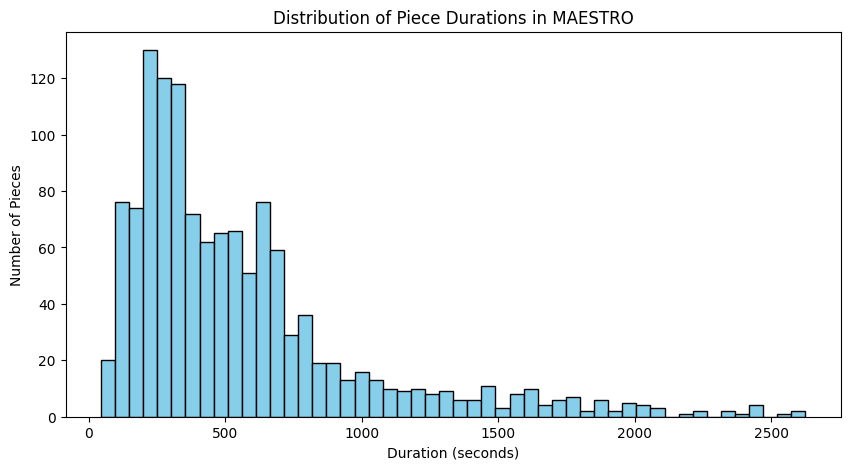

Success!


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# This checks both possible unzipped folder structures just in case!
path_1 = '../data/maestro-v3.0.0.csv'
path_2 = '../data/maestro-v3.0.0/maestro-v3.0.0.csv'

if os.path.exists(path_1):
    csv_path = path_1
elif os.path.exists(path_2):
    csv_path = path_2
else:
    csv_path = None

if csv_path:
    # Load the MAESTRO dataset
    metadata = pd.read_csv(csv_path)
    
    # Create the Duration Histogram
    plt.figure(figsize=(10, 5))
    plt.hist(metadata['duration'], bins=50, color='skyblue', edgecolor='black')
    plt.title('Distribution of Piece Durations in MAESTRO')
    plt.xlabel('Duration (seconds)')
    plt.ylabel('Number of Pieces')
    plt.show()
    
    print("Success!")
else:
    print("Can't find the CSV in the data folder")

Analyzing music file: 2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi ... please wait a moment!


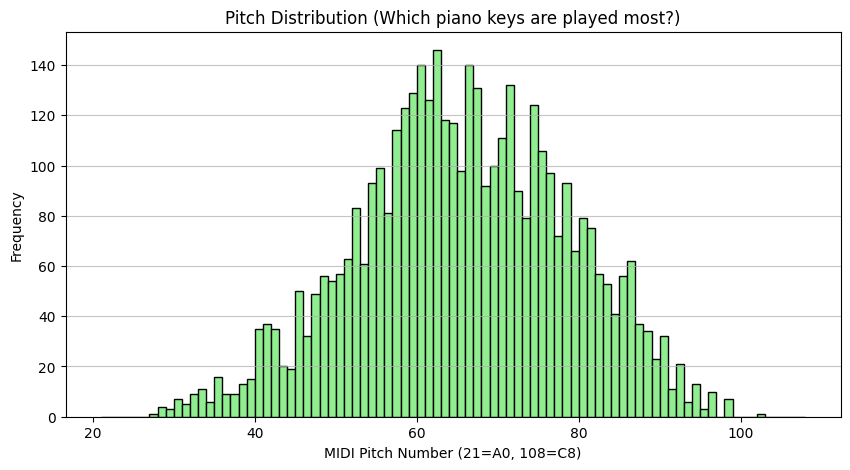

Success!


In [18]:
import pretty_midi
import numpy as np
import os

# We will use the exact same folder where we successfully found the CSV
base_folder = os.path.dirname(csv_path)

# Let's analyze the very first MIDI file listed in your CSV
first_midi_filename = metadata['midi_filename'].iloc[0]
first_midi_path = os.path.join(base_folder, first_midi_filename)

try:
    print(f"Analyzing music file: {first_midi_filename} ... please wait a moment!")
    
    # Load the MIDI file
    midi_data = pretty_midi.PrettyMIDI(first_midi_path)
    
    # Extract all the notes played by the piano
    all_pitches = []
    for instrument in midi_data.instruments:
        if not instrument.is_drum:
            for note in instrument.notes:
                all_pitches.append(note.pitch)
                
    # Create the Pitch Distribution Histogram
    plt.figure(figsize=(10, 5))
    plt.hist(all_pitches, bins=np.arange(21, 109), color='lightgreen', edgecolor='black')
    plt.title('Pitch Distribution (Which piano keys are played most?)')
    plt.xlabel('MIDI Pitch Number (21=A0, 108=C8)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
    
    print("Success!")

except Exception as e:
    print(f"Oops! Something went wrong: {e}")

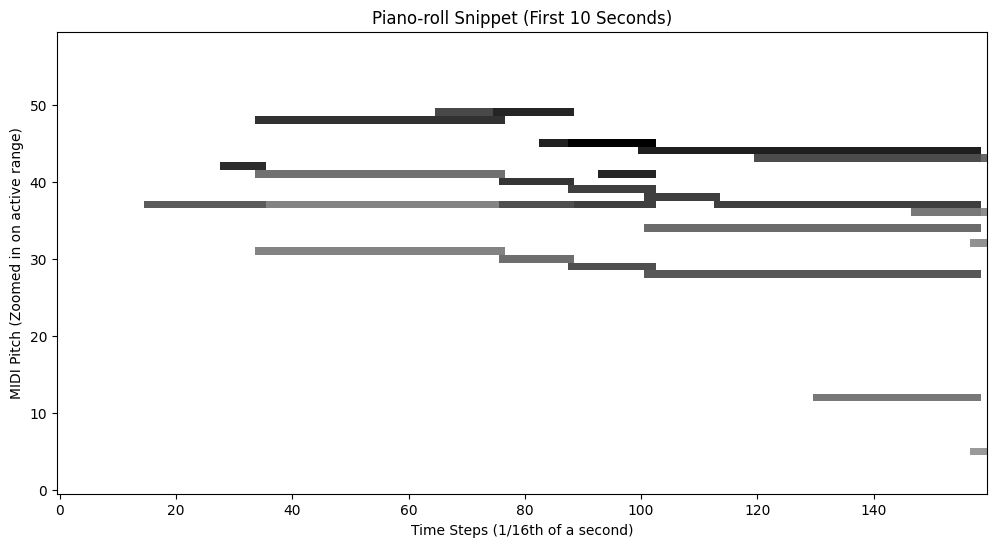

Piano-roll Shape: (128, 11263)
Success! This grid of numbers is what we will feed into your AI model.


In [6]:
import matplotlib.pyplot as plt

def generate_pianoroll(midi_data, fs=16):
    # This function converts MIDI into a 2D matrix (Piano-roll)
    # We use 128 rows to cover all possible MIDI pitches
    return midi_data.get_piano_roll(fs=fs)

try:
    # Use the midi_data we loaded in the previous step
    piano_roll = generate_pianoroll(midi_data)
    
    # Let's look at a small "snippet" of the music (the first 10 seconds)
    # 10 seconds * 16 samples/second = 160 columns
    snippet = piano_roll[30:90, 0:160] 

    plt.figure(figsize=(12, 6))
    plt.imshow(snippet, cmap='gray_r', aspect='auto', origin='lower')
    plt.title('Piano-roll Snippet (First 10 Seconds)')
    plt.xlabel('Time Steps (1/16th of a second)')
    plt.ylabel('MIDI Pitch (Zoomed in on active range)')
    plt.show()

    print(f"Piano-roll Shape: {piano_roll.shape}")
    print("Success! This grid of numbers is what we will feed into our AI model.")

except Exception as e:
    print(f"Error generating piano-roll: {e}")

In [20]:
def create_dataset(piano_roll, sequence_length=100):
    # This prepares the data for an AI: 
    # It takes 100 time-steps of music (Input) 
    # to predict the very next time-step (Target)
    inputs = []
    targets = []
    for i in range(piano_roll.shape[1] - sequence_length):
        inputs.append(piano_roll[:, i:i + sequence_length])
        targets.append(piano_roll[:, i + sequence_length])
    return np.array(inputs), np.array(targets)

# Testing the creator on our snippet
X, y = create_dataset(piano_roll[:, :500]) # Testing with just a small part
print(f"Input Shape (Batches, Keys, Time): {X.shape}")
print(f"Target Shape (Batches, Keys): {y.shape}")
print("\nLessgooo! Our data is fully preprocessed and ready for Model Building.")

Input Shape (Batches, Keys, Time): (400, 128, 100)
Target Shape (Batches, Keys): (400, 128)

Lessgooo! Our data is fully preprocessed and ready for Model Building.
